# Step 1 Data Processing
Apply appropriate techniques to preprocess data (e.g., normalization, standardization)

In [12]:
## Data Processing libraries
#!pip install -U scikit-learn

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold

passenger = pd.read_csv("titanic_augmented.csv")

passenger.shape

(891, 26)

In [13]:
passenger.tail(6)
passenger.iloc[:, 0:13]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,name_length
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,23
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,51
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,22
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,44
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,21
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,28
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,40
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,21


In [14]:
passenger.iloc[:, 13:25]

,title,title_group,family_size,is_alone,ticket_group_size,fare_per_person,age_fare_ratio,cabin_deck,cabin_room_number,booking_reference,service_id,cabin_score
0,Mr,Mr,2,0,1,7.250,3.034483,Unknown,NaN,92490,221958,6.134152
1,Mrs,Mrs,2,0,1,71.283,0.533084,C,85.0,15655423,771155,4.182430
2,Miss,Miss,1,1,1,7.925,3.280757,Unknown,NaN,90218500,231932,9.327285
3,Mrs,Mrs,2,0,2,26.550,0.659134,C,123.0,2493079,465838,8.660639
4,Mr,Mr,1,1,1,8.050,4.347826,Unknown,NaN,59517148,359178,0.452187
...,...,...,...,...,...,...,...,...,...,...,...,...
886,Rev,Other,1,1,1,13.000,2.076923,Unknown,NaN,83757278,538661,4.308875
887,Miss,Miss,1,1,1,30.000,0.633333,B,42.0,91664020,498929,2.487143
888,Miss,Miss,4,0,2,11.725,0.000000,Unknown,NaN,55618889,680466,6.171450
889,Mr,Mr,1,1,1,30.000,0.866667,C,148.0,94737372,673695,7.067772


In [15]:
passenger.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,is_alone,ticket_group_size,fare_per_person,age_fare_ratio,cabin_deck,cabin_room_number,booking_reference,service_id,cabin_score,name_word_count
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,...,891.000000,891.000000,891.000000,891.000000,891,200.00000,8.910000e+02,891.000000,891.000000,891.000000
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,...,NaN,NaN,NaN,NaN,9,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,...,NaN,NaN,NaN,NaN,Unknown,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,...,NaN,NaN,NaN,NaN,687,NaN,NaN,NaN,NaN,NaN
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,...,0.602694,1.787879,17.789001,1.572536,NaN,50.49000,5.108118e+07,536369.988777,4.956762,4.067340
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,...,0.489615,1.361142,21.218127,1.661773,NaN,35.39497,2.838174e+07,261551.630299,2.915177,1.168866
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,...,0.000000,1.000000,0.000000,0.000000,NaN,2.00000,9.249000e+04,102869.000000,0.046320,3.000000
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,...,0.000000,1.000000,7.762500,0.116026,NaN,22.00000,2.831962e+07,299638.000000,2.325861,3.000000
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,...,1.000000,1.000000,8.850000,1.175795,NaN,43.00000,5.128853e+07,535564.000000,4.954913,4.000000
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,...,1.000000,2.000000,24.288000,2.543045,NaN,77.25000,7.493131e+07,757663.000000,7.479345,4.000000


In [27]:
passenger.corr()

ValueError: could not convert string to float: 'Braund, Mr. Owen Harris'

In [ ]:
passenger.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PassengerId        891 non-null    int64  
 1   Survived           891 non-null    int64  
 2   Pclass             891 non-null    int64  
 3   Name               891 non-null    object 
 4   Sex                891 non-null    object 
 5   Age                714 non-null    float64
 6   SibSp              891 non-null    int64  
 7   Parch              891 non-null    int64  
 8   Ticket             891 non-null    object 
 9   Fare               891 non-null    float64
 10  Cabin              204 non-null    object 
 11  Embarked           889 non-null    object 
 12  name_length        891 non-null    int64  
 13  title              891 non-null    object 
 14  title_group        891 non-null    object 
 15  family_size        891 non-null    int64  
 16  is_alone           891 non

In [ ]:
# Drop Irrelevant, Weak, Redundant Features
drop_cols = [
    "PassengerId",    # identifier
    "Name",           # title already extracted
    "Ticket",         # too high-cardinality
    "Cabin",           # raw cabin string; usually replaced by deck
    "name_length",                  # Too many missing data and it is redundant to the decomposed ones
    "name_word_count",      # Weak predictor
    "title",           # Keep the title_group instead
    "cabin_room_number",
    "booking_reference",
    "service_id"
]

cols_dropping = [col for col in drop_cols if col in passenger.columns]
passenger_clean = passenger.drop(columns=cols_dropping)


# Separate Predictors and Response 
target = "Survived"
X = passenger_clean.drop(columns=[target])
y = passenger_clean[target]

# separate numeric and categories for future pipelining
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

if 'Pclass' in num_features:
    num_features.remove('Pclass')
    cat_features.append('Pclass')

# Pipelining
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, num_features),
        ('cat', categorical_pipeline, cat_features)
    ]
)

preprocessing_only = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

# Splitting train/test 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y   # preserves class ratio
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("Survival rate in full dataset:", y.mean())
print("Survival rate in training set:", y_train.mean())
print("Survival rate in test set:", y_test.mean())

# CV re-sampling
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#StratifiedKFold(n_splits=10)


# example placeholder for a model
logreg_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),   # from earlier step
    ('model', LogisticRegression(max_iter=1000))
])

# useful in the future
# scores = cross_val_score(
#     logreg_pipeline,
#     X_train,
#     y_train,
#     cv=cv,
#     scoring='accuracy'
# )

# print("CV Accuracy:", scores)
# print("Mean Accuracy:", scores.mean())

##Check for missing value]
# X_check = preprocessing_only.fit_transform(X_train)
# X_check.shape
# np.isnan(X_check).sum()

Training set size: (668, 15)
Test set size: (223, 15)
Survival rate in full dataset: 0.3838383838383838
Survival rate in training set: 0.38323353293413176
Survival rate in test set: 0.38565022421524664


# Step 2 Data Splitting and Resampling
Split the dataset into training and test sets (25% test) and use appropriate resampling techniques (e.g., k-fold cross-validation) to ensure robust model evaluation.

# Step 3 Model Building

## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

#### Step 1 Start with pipeling for LogReg

In [ ]:

logreg_pipe = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

#### Step 2 The baseline cross-validation result before tuning step

In [ ]:

logreg_cv_scores = cross_val_score(
    logreg_pipe,
    X_train,
    y_train,
    cv=cv,
    scoring='accuracy'
)

print("Baseline Logistic Regression Cross-Validate scores:", logreg_cv_scores)
print("Mean Cross-Validate accuracy:", logreg_cv_scores.mean())

Baseline Logistic Regression Cross-Validate scores: [0.84328358 0.82835821 0.85074627 0.85714286 0.78947368]
Mean Cross-Validate accuracy: 0.8338009202109753


The model performs consistently across folds, with scores mostly between 0.82–0.86 with one that is 0.7895 indicates some variance but no harm overall.

So, given the result from the basaline CV, the model achieved a mean accuracy of 83.4% and a relatively small variance across folds. This could mean that the linear decision boundary generalizes well in a reasonable indicator and that the augmented features provide good linear separatbility between survivors and those who did not.

#### Step 3 Making Hyperparameter Tuning for the model

In [ ]:
import warnings
warnings.filterwarnings('ignore')

logreg_param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs', 'liblinear']
}

logreg_grid = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=logreg_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

logreg_grid.fit(X_train, y_train)


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'SibSp',
                                                                          'Parch',
                                                                          'Fare',
                                                                          'family_size',
                                                                          'is_alone',
                                                                          'ticket_group_size',
                                                                          'fare_per_person',
                                                                          'age_fare_r...
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Sex',
                                                                          'Embarked',
                                                                          'title_group',
                                                                          'cabin_deck',
                                                                          'Pclass'])])),
                                       ('model',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid={'model__C': [0.01, 0.1, 1, 10, 100],
                         'model__penalty': ['l2'],
                         'model__solver': ['lbfgs', 'liblinear']},
             scoring='accuracy')

In [ ]:
# View the Best performance of the model fitting
print("Best parameters:", logreg_grid.best_params_)
print("Best CV accuracy:", logreg_grid.best_score_)

Best parameters: {'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best CV accuracy: 0.8353159016945348


With the best value of 10, this tells us that the model performs best with weaker regularization, and it means the data itself is reliable enough with strong and indicative features. This is also why L2 penalty is being used here.  
So the grid search result indicated tha C=10 applying L2 regularization with lbfgs solve can improve the CV accuracy to 83.5%.

#### Step 4 Tuned Model Evaluation on Test Data

In [ ]:
#from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

logreg_best = logreg_grid.best_estimator_

y_pred_lr = logreg_best.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))


Test Accuracy: 0.8295964125560538

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86       137
           1       0.78      0.78      0.78        86

    accuracy                           0.83       223
   macro avg       0.82      0.82      0.82       223
weighted avg       0.83      0.83      0.83       223


Confusion Matrix:
 [[118  19]
 [ 19  67]]


- Final Test: The tuned Logistic Regression model achieved a test accuracy of 82.5%, closely matching its cross-validation performance. This consistency indicates that the model generalizes well on unseen data and that no substantial overfitting is present.  

- Classification Report: The model shows stronger performance for predicting non-survivors (F1 = 0.86) than survivors (F1 = 0.77), reflecting the class imbalance in the dataset and the linear nature of the classifier. Despite this, recall for the positive class (0.78) indicates that the model is reasonably effective at identifying survivors.  

- Confusion Matrix: 
    - 117 true negatives — correctly predicted deaths
    - 67 true positives — correctly predicted survivors
    - 20 false positives — predicted survived but actually died
    - 19 false negatives — predicted died but actually survived

The confusion matrix shows balanced error rates across both classes, with 19 false negatives and 20 false positives. The model captures the underlying survival patterns well without disproportionately favoring one class.

#### Step 5 ROC Curve and AUC

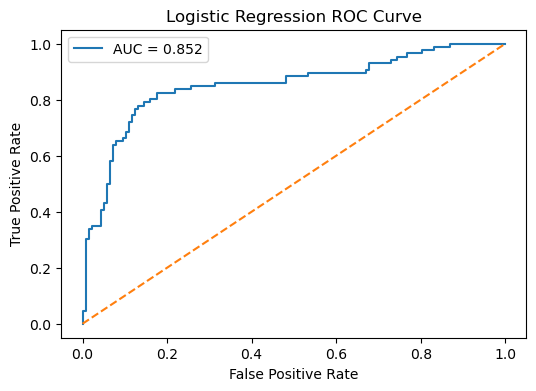

Exception ignored in: <function ResourceTracker.__del__ at 0x1076a9da0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104c2dda0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105405da0>
Traceback (most recent call last

In [ ]:
# from sklearn.metrics import roc_curve, auc
# import matplotlib.pyplot as plt

y_pred_proba = logreg_best.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.show()


- AUC of 0.85 is considered strong.
- Indicates good ranking ability: survivors generally receive higher predicted probabilities than non-survivors.
- Confirms that Logistic Regression captures meaningful separation even when linear.
\
\
The ROC curve demonstrates strong discriminative ability with an AUC of 0.85, indicating that the model assigns higher survival probabilities to true survivors most of the time. This suggests that the linear decision boundary is effective for ranking passenger risk.

# Last Step Final Summary
Logistic Regression produced a strong linear baseline for the Titanic classification task. The baseline model achieved a mean cross-validated accuracy of 83.3%, and after hyperparameter tuning, the optimal configuration (C = 10, L2 penalty, lbfgs solver) improved performance slightly to 83.5%. The test accuracy (82.5%) closely matched the CV results, indicating stable generalization and no overfitting. The classification report shows better performance on the majority class (non-survivors), although recall for survivors remained reasonably high (0.78). The ROC-AUC score of 0.85 further confirms strong discriminative ability. Overall, Logistic Regression provides a reliable and interpretable baseline model that effectively leverages the engineered features in the augmented dataset.